<a href="https://colab.research.google.com/github/amosagekouassi-source/DI-Bootcamp/blob/master/Exercises_XP_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercises XP: Introduction to LLMs

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells containing **TODO** markers need your input.


## 👩‍🏫👩🏿‍🏫 What you’ll learn
- Understand what Large Language Models (LLMs) can do.
- Review the Transformer architecture and the tokenization pipeline.
- Differentiate between pretraining and fine-tuning.
- Generate text with a pretrained language model.


## 🛠️ What you will create
- Markdown answers describing key NLP concepts.
- Python code that loads GPT-2 (or a similar causal LM) and performs basic tokenization and generation.


> **Learning point**
> Work through the exercises sequentially. Run installation cells only once, then focus on filling each TODO before executing the corresponding code.


## 🌟 Exercise 1 · What are Large Language Models?


### 1.1 Define LLMs
Large Language Models (LLMs) are AI systems trained on vast amounts of text data to understand and generate human-like language. They are designed to solve tasks such as translation, summarization, question answering, and creative writing by predicting the probability of a sequence of words.

### 1.2 Prefilled · install core libraries
Run once to install `transformers`, `torch`, and supporting utilities exactly as in the enoncé.


In [1]:
%pip install --quiet transformers matplotlib --upgrade


### 1.3 Load GPT for causal text generation
Reuse the snippet from the platform: declare the model name, tokenizer, and model weights.


In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
import torch
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

model_name = 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

if None in (model_name, tokenizer, model):
    raise ValueError("Fill in model_name, tokenizer, and model before continuing.")

print(f"\nModel '{model_name}' loaded successfully!")
print("""
GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.
""")

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]


Model 'gpt2' loaded successfully!

GPT-2 is a causal language model, meaning it predicts the next word in a sequence.
It has been trained on a diverse dataset and can generate coherent, contextually relevant text.



## 🌟 Exercise 2 · Transformer Architecture and Tokenization


Tokenization is the process of breaking down raw text into smaller units called tokens (words, subwords, or characters). These tokens are then converted into numerical IDs that the model can process mathematically.

Original Text: The quick brown fox jumps over the lazy dog.
Tokens: ['The', 'Ġquick', 'Ġbrown', 'Ġfox', 'Ġjumps', 'Ġover', 'Ġthe', 'Ġlazy', 'Ġdog', '.']
Token IDs: [464, 2068, 7586, 21831, 18045, 625, 262, 16931, 3290, 13]


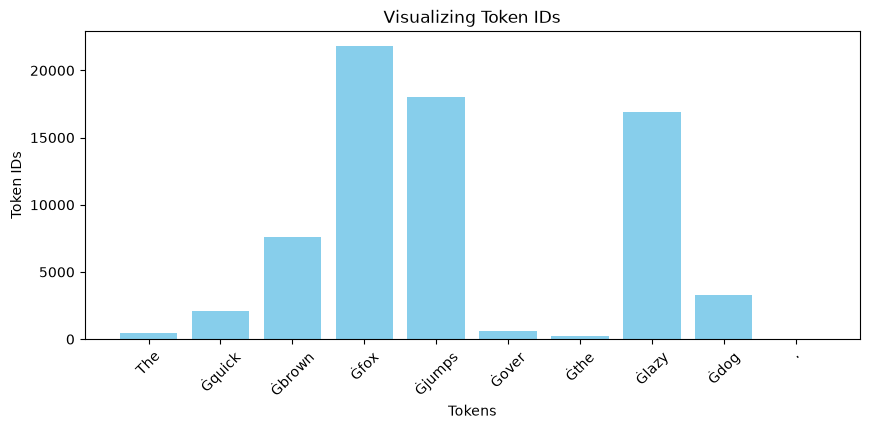

In [3]:
text = "The quick brown fox jumps over the lazy dog."
if text is None:
    raise ValueError("Define the variable `text` with a short sentence.")

tokens = tokenizer.tokenize(text)
token_ids = tokenizer.convert_tokens_to_ids(tokens)

print(f"Original Text: {text}")
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

x_label = "Tokens"
y_label = "Token IDs"
title = "Visualizing Token IDs"

if None in (x_label, y_label, title):
    raise ValueError("Set x_label, y_label, and title before plotting.")

plt.figure(figsize=(10, 4))
plt.bar(tokens, token_ids, color="skyblue")
plt.xlabel(x_label)
plt.ylabel(y_label)
plt.title(title)
plt.xticks(rotation=45)
plt.show()

## 🌟 Exercise 3 · Token IDs and special prefixes


In [4]:
if 'tokens' not in globals() or 'token_ids' not in globals():
    raise ValueError("Run Exercise 2 to define `tokens` and `token_ids` first.")

for token, tid in zip(tokens, token_ids):
    print(f"Token: {token:<15} | ID: {tid}")

Token: The             | ID: 464
Token: Ġquick          | ID: 2068
Token: Ġbrown          | ID: 7586
Token: Ġfox            | ID: 21831
Token: Ġjumps          | ID: 18045
Token: Ġover           | ID: 625
Token: Ġthe            | ID: 262
Token: Ġlazy           | ID: 16931
Token: Ġdog            | ID: 3290
Token: .               | ID: 13


The `Ġ` prefix in GPT-style vocabularies (like Byte-Pair Encoding) represents a space character at the beginning of a token. It helps the model distinguish between a word at the start of a sentence and the same word preceded by a space.

## 🌟 Exercise 4 · Pre-training vs. Fine-tuning

**Pre-training:** This is the first phase where the model is trained on a massive amount of unlabeled text data (like the entire internet). The goal is for it to learn the structure of language, grammar, and general knowledge by predicting missing words. At this stage, the model is very powerful but general-purpose.

**Fine-tuning:** This phase involves taking the pre-trained model and training it again on a much smaller, specific dataset for a precise task (e.g., sentiment analysis, translation, or medical Q&A). We adjust the parameters so that it becomes an expert in that specific domain.

## 🌟 Exercise 5 · Generate simple text


Create a fresh prompt, run the generator, and observe how the model extends your sentence token by token.


In [5]:
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1,
)

input_text = "Deep learning is a subset of machine learning that"
if input_text is None:
    raise ValueError("Set `input_text` before generating.")

gen_kwargs = {
    "max_new_tokens": 50,
    "temperature": 0.7,
    "top_p": 0.9,
    "do_sample": True,
}

output_ids = generator(input_text, **gen_kwargs)
output_text = output_ids[0]["generated_text"]

print(f"Input: {input_text}")
print(f"Generated Output: {output_text}")

[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'temperature', 'top_p', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe

Input: Deep learning is a subset of machine learning that
Generated Output: Deep learning is a subset of machine learning that can be applied to other kinds of problems. The problem of choosing a correct solution is one of the most complex ones we have to deal with in any field. However, it is one that is difficult to solve. It is a subset of machine learning
